In [1366]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)


#Data Cleaning and Exploration


df= pd.read_csv(r'C:\Users\Jethro Madusha\Downloads\July Amdari\Novapay-fraudlent\data\nova_pay_combined.csv',parse_dates=['timestamp' ])

df.head(5)



,transaction_id,customer_id,timestamp,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,device_id,new_device,ip_address,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,is_fraud
0,fee8542d-8ee6-4b0d-9671-c294dd08ed26,402cccc9-28de-45b3-9af7-cc5302aa1f93,2022-10-03 18:40:59.468549+00:00,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,9f292dcc-3297-4947-a260-6a1ef69041ff,False,221.78.171.180,US,False,0.123,standard,263,0.522,0,0.223,0,0,0.0,0
1,bfdb9fc1-27fe-4a85-b043-4d813d679259,67c2c6b3-ef0a-4777-a3f1-c84a851bb6ad,2022-10-03 20:39:38.468549+00:00,CA,CAD,MXN,web,208.51,154.29,4.24,12.758621,3a95b9f5-309f-4684-a46d-e2ff2435bf78,True,120.12.20.29,CA,False,0.569,standard,947,0.475,0,0.268,0,1,0.0,0
2,fc855034-3ea5-4993-9afa-b511d93fe5e8,6d0d9b27-fa26-45f8-93b1-2df29d182d9c,2022-10-03 23:02:43.468549+00:00,US,USD,CNY,mobile,160.33,160.33,2.70,7.142857,a4737752-9aac-43ed-9d8b-2ccdffc24052,False,223.96.181.93,US,False,0.437,enhanced,367,0.939,0,0.176,0,0,0.0,0
3,2cf8c08e-42ec-444d-a755-34b9a2a0a4ca,7bd5200c-5d19-44f0-9afe-8b339a05366b,2022-10-04 01:08:53.468549+00:00,US,USD,EUR,mobile,59.41,59.41,2.22,0.925926,6aeb85a3-5603-4221-896c-9e6882764f1a,False,186.228.15.74,US,False,0.594,standard,147,0.551,0,0.391,0,0,0.0,0
4,d907a74d-b426-438d-97eb-dbe911aca91c,70a93d26-8e3a-4179-900c-a4a7a74d08e5,2022-10-04 09:35:03.468549+00:00,US,USD,INR,mobile,200.96,200.96,3.61,83.333333,a5b9250e-dbe0-4c5f-a6e7-5492b7349402,False,11.82.47.62,US,False,0.121,enhanced,257,0.894,0,0.257,0,0,0.0,0


In [1367]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11400 entries, 0 to 11399
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   transaction_id             11400 non-null  object 
 1   customer_id                11400 non-null  object 
 2   timestamp                  11371 non-null  object 
 3   home_country               11400 non-null  object 
 4   source_currency            11400 non-null  object 
 5   dest_currency              11400 non-null  object 
 6   channel                    11400 non-null  object 
 7   amount_src                 11400 non-null  object 
 8   amount_usd                 11095 non-null  float64
 9   fee                        11105 non-null  float64
 10  exchange_rate_src_to_dest  11400 non-null  float64
 11  device_id                  11400 non-null  object 
 12  new_device                 11400 non-null  bool   
 13  ip_address                 11095 non-null  obj

The dataset contains missing values across several variables, indicating that some transaction records are incomplete. The **amount_usd** and **ip_address** columns have the highest number of missing values, with **305 missing entries each**. Similarly, the **ip_country**, **kyc_tier**, **fee**, and **device_trust_score** columns also contain a substantial number of missing records. In comparison, the **timestamp** column has relatively few missing values, with only **29 missing entries**. These missing values should be appropriately handled during the data preprocessing stage to ensure the accuracy and reliability of subsequent analyses and predictive modeling.


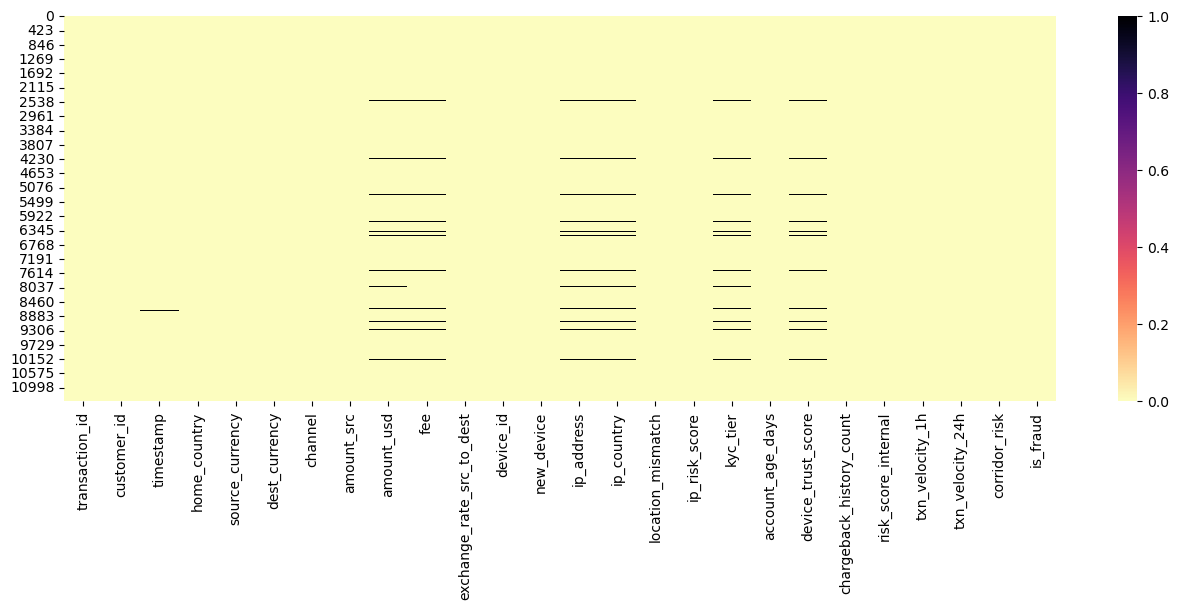

In [1368]:
# Visualize the missing data
plt.figure(figsize =(16,5))
sns.heatmap(df.isnull(), cbar=True, cmap="magma_r");

In [1369]:
df[['amount_usd','amount_src']].dtypes
df['amount_src'] =pd.to_numeric(df['amount_src'], errors='coerce')

df['amount_usd']/df['amount_src']

0        1.000000
1        0.739965
2        1.000000
3        1.000000
4        1.000000
           ...   
11395    1.000000
11396    0.740008
11397    0.739995
11398    1.000000
11399    1.000000
Length: 11400, dtype: float64

In [1370]:
 
df['source_currency'].value_counts()



source_currency
USD    8031
GBP    2139
CAD    1230
Name: count, dtype: int64

In [1371]:
rates = round((df['amount_usd']/df['amount_src']).groupby(df['source_currency']).mean(),1)
rates.values



array([0.7, 1.2, 1. ])

In [1372]:
df['amount_usd'] = df['amount_usd'].fillna(
    df['amount_src'] * df['source_currency'].map(rates)
)

df['amount_usd'] = df['amount_usd'].fillna(df['amount_usd'].mean())

df.isnull().sum()


transaction_id                 0
customer_id                    0
timestamp                     29
home_country                   0
source_currency                0
dest_currency                  0
channel                        0
amount_src                     4
amount_usd                     0
fee                          295
exchange_rate_src_to_dest      0
device_id                      0
new_device                     0
ip_address                   305
ip_country                   301
location_mismatch              0
ip_risk_score                  0
kyc_tier                     300
account_age_days               0
device_trust_score           295
chargeback_history_count       0
risk_score_internal            0
txn_velocity_1h                0
txn_velocity_24h               0
corridor_risk                  0
is_fraud                       0
dtype: int64

In [1373]:
df.select_dtypes(include='object').columns 

Index(['transaction_id', 'customer_id', 'timestamp', 'home_country',
       'source_currency', 'dest_currency', 'channel', 'device_id',
       'ip_address', 'ip_country', 'kyc_tier'],
      dtype='object')

In [1374]:
for col in data.select_dtypes(include='object').columns:
    print(df[col].value_counts())

transaction_id
805e3831-dd30-44cd-9db8-122425ec3a36    2
5263bbdf-1a0a-48a3-8309-3f6b5b57d4a6    2
ba28f0a4-1ee4-413a-b371-11449236ed6f    2
cc815d51-f920-4314-a84a-28730c76bd08    2
35a684af-4d53-4ca4-a41a-5409c9e209c7    2
                                       ..
fd00ac8a-b759-43f0-9eb8-cd6e145ae7b1    1
81fedead-17cd-4f38-96cb-144862eed399    1
c83499f1-2bc2-403c-a676-2e5b0a24de7e    1
37330308-95cd-45c8-b4ec-abd587560373    1
9e2e4e1a-f91f-42c2-a607-9437b335dfcc    1
Name: count, Length: 11200, dtype: int64
customer_id
402cccc9-28de-45b3-9af7-cc5302aa1f93    1510
d71c91b4-fee8-4104-9856-a5c6109a62e3    1355
7041b9c1-3719-4ca8-9a6b-811b47cea6c0    1345
6d0d9b27-fa26-45f8-93b1-2df29d182d9c    1066
af8ca4c4-8703-4c55-b66c-2b76cd70040d     915
                                        ... 
46d39a54-b2b3-468a-ba81-537f1423291f       1
bd0bfc02-abd0-4d9b-8404-c8be595102ea       1
111a447b-5612-41a6-b7ea-a70afaf4b731       1
361b3f41-8185-4dee-83e6-fb387c0e2a4a       1
52b25b45-db2d-44ee-a

In [1375]:
### Categorical Variables cleaning

category_cols_to_upper = [
    'home_country', 'source_currency', 'dest_currency',
    'channel', 'ip_country', 'kyc_tier'
]

for col in category_cols_to_upper:
    data_clean[col] = data_clean[col].str.upper()

    # Fix known typos after uppercasing
data_clean['channel'] = data_clean['channel'].replace({
    'MOBILLE': 'MOBILE',
    'WEEB': 'WEB'
})

data_clean['kyc_tier'] = data_clean['kyc_tier'].replace({
    'ENHANCD': 'ENHANCED',
    'STANDRD': 'STANDARD'
})

# Remove commas and convert amount_src to numeric
data_clean['amount_src'] = (
    data_clean['amount_src']
    .astype(str)
    .str.replace(',', '', regex=False)
)

data_clean['amount_src'] = pd.to_numeric(data_clean['amount_src'], errors='coerce')

In [1376]:
# Convert timestamp to datetime
data_clean['timestamp'] = pd.to_datetime(
    data_clean['timestamp'],
    errors='coerce',
    utc=True
)
# Check timestamp range
data_clean['timestamp'].min(), data_clean['timestamp'].max()


(Timestamp('2022-10-03 18:40:59.468549+0000', tz='UTC'),
 Timestamp('2025-12-16 00:13:41.468549+0000', tz='UTC'))

In [1377]:
# Set invalid risk score values outside 0-1 to missing
score_cols = [
    'ip_risk_score',
    'device_trust_score',
    'risk_score_internal',
    'corridor_risk'
]

for col in score_cols:
    data_clean.loc[
        (data_clean[col] < 0) | (data_clean[col] > 1),
        col
    ] = np.nan

In [1378]:
# Set invalid negative fee values to missing
data_clean.loc[data_clean['fee'] < 0, 'fee'] = np.nan

In [1379]:
# Set invalid negative transaction velocity values to missing
data_clean.loc[data_clean['txn_velocity_1h'] < 0, 'txn_velocity_1h'] = np.nan
data_clean.loc[data_clean['txn_velocity_24h'] < 0, 'txn_velocity_24h'] = np.nan

In [1380]:
# Check cleaned data information
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11200 entries, 0 to 11199
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11200 non-null  object             
 1   customer_id                11200 non-null  object             
 2   timestamp                  11140 non-null  datetime64[ns, UTC]
 3   home_country               11168 non-null  object             
 4   source_currency            11200 non-null  object             
 5   dest_currency              11200 non-null  object             
 6   channel                    11163 non-null  object             
 7   amount_src                 11200 non-null  float64            
 8   amount_usd                 10900 non-null  float64            
 9   fee                        10810 non-null  float64            
 10  exchange_rate_src_to_dest  11200 non-null  float64            
 11  de

In [1381]:
# Re-check missing values after cleaning
clean_missing_values = pd.DataFrame({
    'Missing Count': data_clean.isnull().sum(),
    'Missing Percentage': (data_clean.isnull().sum() / len(data_clean) * 100).round(2)
})

clean_missing_values[clean_missing_values['Missing Count'] > 0].sort_values(
    by='Missing Count', ascending=False
)

,Missing Count,Missing Percentage
device_trust_score,490,4.38
fee,390,3.48
ip_country,331,2.96
kyc_tier,329,2.94
ip_address,300,2.68
amount_usd,300,2.68
txn_velocity_1h,200,1.79
ip_risk_score,200,1.79
timestamp,60,0.54
transaction_hour,60,0.54


#After cleaning, the dataset still contains missing values across several columns. The missing percentages are relatively low, with the highest missingness found in device_trust_score. These missing values will not be imputed immediately because imputation should be handled carefully during the preprocessing stage to avoid data leakage. For now, the cleaned dataset preserves missing values so that they can be treated properly within the modeling pipeline.

In [1382]:
# Re-check selected categorical columns after cleaning
for col in categorical_cols:
    print(f"\n{col}:")
    print(data_clean[col].value_counts(dropna=False))


home_country:
home_country
US     7852
UK     2104
CA     1212
NaN      32
Name: count, dtype: int64

source_currency:
source_currency
USD    7875
GBP    2111
CAD    1214
Name: count, dtype: int64

dest_currency:
dest_currency
NGN    1447
INR    1304
USD    1302
CNY    1297
PHP    1290
GBP    1273
CAD    1260
EUR    1177
MXN     850
Name: count, dtype: int64

channel:
channel
MOBILE    6395
WEB       3766
ATM       1002
NaN         37
Name: count, dtype: int64

ip_country:
ip_country
US     6761
UK     2390
CA     1718
NaN     331
Name: count, dtype: int64

kyc_tier:
kyc_tier
STANDARD    7985
ENHANCED    1839
LOW         1047
NaN          329
Name: count, dtype: int64

new_device:
new_device
False    9864
True     1336
Name: count, dtype: int64

location_mismatch:
location_mismatch
False    9375
True     1825
Name: count, dtype: int64


In [1383]:
data_clean['is_fraud'].value_counts(normalize=True).mul(100).round(2)

is_fraud
0    91.12
1     8.88
Name: proportion, dtype: float64

The cleaned dataset remains imbalanced, with non-fraudulent transactions making up 91.12% of the records and fraudulent transactions making up 8.88%. Although fraud cases are the minority class, they are the main class of interest for this project. Therefore, model evaluation will need to prioritize fraud detection performance using metrics such as recall, precision, F1-score, ROC-AUC, and PR-AUC rather than accuracy alone.

In [1384]:
# Save cleaned dataset
data_clean.to_csv('../data/nova_pay_cleaned.csv', index=False)

In [1385]:
# Final quality assurance checks after cleaning
final_quality_checks = {
    'duplicate_rows': data_clean.duplicated().sum(),
    'duplicate_transaction_ids': data_clean['transaction_id'].duplicated().sum(),
    'negative_amount_usd': (data_clean['amount_usd'] < 0).sum(),
    'zero_amount_usd': (data_clean['amount_usd'] == 0).sum(),
    'negative_fee': (data_clean['fee'] < 0).sum(),
    'ip_risk_score_outside_0_1': ((data_clean['ip_risk_score'] < 0) | (data_clean['ip_risk_score'] > 1)).sum(),
    'device_trust_score_outside_0_1': ((data_clean['device_trust_score'] < 0) | (data_clean['device_trust_score'] > 1)).sum(),
    'risk_score_internal_outside_0_1': ((data_clean['risk_score_internal'] < 0) | (data_clean['risk_score_internal'] > 1)).sum(),
    'corridor_risk_outside_0_1': ((data_clean['corridor_risk'] < 0) | (data_clean['corridor_risk'] > 1)).sum(),
    'negative_account_age_days': (data_clean['account_age_days'] < 0).sum(),
    'negative_txn_velocity_1h': (data_clean['txn_velocity_1h'] < 0).sum(),
    'negative_txn_velocity_24h': (data_clean['txn_velocity_24h'] < 0).sum()
}

pd.DataFrame.from_dict(final_quality_checks, orient='index', columns=['Count'])

,Count
duplicate_rows,0
duplicate_transaction_ids,0
negative_amount_usd,0
zero_amount_usd,0
negative_fee,0
ip_risk_score_outside_0_1,0
device_trust_score_outside_0_1,0
risk_score_internal_outside_0_1,0
corridor_risk_outside_0_1,0
negative_account_age_days,0


In [1386]:
# Check for duplicate rows
data.duplicated().sum()

np.int64(200)

In [1387]:
# Check for duplicate transaction IDs
data['transaction_id'].duplicated().sum()

np.int64(200)

In [1388]:
# Check fraud vs non-fraud distribution
data['is_fraud'].value_counts()

is_fraud
0    10403
1      997
Name: count, dtype: int64

In [1389]:
# Check fraud vs non-fraud percentage
data['is_fraud'].value_counts(normalize=True).mul(100).round(2)

is_fraud
0    91.25
1     8.75
Name: proportion, dtype: float64

In [1390]:
# Check unique values in selected categorical columns
categorical_cols = [
    'home_country', 'source_currency', 'dest_currency', 'channel',
    'ip_country', 'kyc_tier', 'new_device', 'location_mismatch'
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(data[col].value_counts(dropna=False))


home_country:
home_country
US         7940
UK         2119
CA         1221
 US          68
unknown      32
 UK          13
 CA           7
Name: count, dtype: int64

source_currency:
source_currency
USD    8031
GBP    2139
CAD    1230
Name: count, dtype: int64

dest_currency:
dest_currency
NGN    1474
USD    1328
INR    1325
CNY    1324
PHP    1314
GBP    1296
CAD    1282
EUR    1196
MXN     861
Name: count, dtype: int64

channel:
channel
mobile       6366
web          3727
ATM          1008
mobille        60
 mobile        48
MOBILE         47
unknown        37
WEB            36
 web           34
weeb           24
ATm             9
 ATM            4
Name: count, dtype: int64

ip_country:
ip_country
US         6848
UK         2407
CA         1726
NaN         301
 US          49
unknown      33
 UK          18
 CA          15
NAN           2
 nan          1
Name: count, dtype: int64

kyc_tier:
kyc_tier
standard       7931
enhanced       1829
low            1039
NaN             300
stan

In [1391]:
# Summary statistics for numeric columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
amount_usd,11095.0,452.022083,1403.973062,7.230,92.465,163.480000,302.190000,12498.570000
fee,11105.0,100.309441,958.128504,-1.000,2.380,3.500000,5.550000,9999.990000
exchange_rate_src_to_dest,11400.0,167.540397,382.023827,0.592,1.000,7.142857,73.529412,1388.888889
ip_risk_score,11400.0,0.396726,0.270507,0.004,0.209,0.325000,0.487000,1.200000
account_age_days,11400.0,393.793158,342.348393,1.000,147.000,298.000000,661.000000,1095.000000
device_trust_score,11105.0,0.653681,0.273012,-0.100,0.515,0.658000,0.894000,0.999000
chargeback_history_count,11400.0,0.048509,0.256194,0.000,0.000,0.000000,0.000000,2.000000
risk_score_internal,11400.0,0.267134,0.142983,0.000,0.169,0.223000,0.391000,0.900000
txn_velocity_1h,11400.0,0.458333,1.524494,-1.000,0.000,0.000000,0.000000,8.000000
txn_velocity_24h,11400.0,0.723509,1.958390,0.000,0.000,0.000000,0.000000,11.000000


In [1392]:
# Check for invalid or suspicious numeric values
quality_checks = {
    'negative_amount_usd': (data['amount_usd'] < 0).sum(),
    'zero_amount_usd': (data['amount_usd'] == 0).sum(),
    'negative_fee': (data['fee'] < 0).sum(),
    'ip_risk_score_outside_0_1': ((data['ip_risk_score'] < 0) | (data['ip_risk_score'] > 1)).sum(),
    'device_trust_score_outside_0_1': ((data['device_trust_score'] < 0) | (data['device_trust_score'] > 1)).sum(),
    'risk_score_internal_outside_0_1': ((data['risk_score_internal'] < 0) | (data['risk_score_internal'] > 1)).sum(),
    'corridor_risk_outside_0_1': ((data['corridor_risk'] < 0) | (data['corridor_risk'] > 1)).sum(),
    'negative_account_age_days': (data['account_age_days'] < 0).sum(),
    'negative_txn_velocity_1h': (data['txn_velocity_1h'] < 0).sum(),
    'negative_txn_velocity_24h': (data['txn_velocity_24h'] < 0).sum()
}

pd.DataFrame.from_dict(quality_checks, orient='index', columns=['Count'])

,Count
negative_amount_usd,0
zero_amount_usd,0
negative_fee,101
ip_risk_score_outside_0_1,204
device_trust_score_outside_0_1,204
risk_score_internal_outside_0_1,0
corridor_risk_outside_0_1,0
negative_account_age_days,0
negative_txn_velocity_1h,204
negative_txn_velocity_24h,0


In [1393]:
# Create a copy for cleaning
data_clean = data.copy()
# Standardize column names
data_clean.columns = data_clean.columns.str.strip().str.lower()
# Remove duplicate rows
data_clean = data_clean.drop_duplicates().reset_index(drop=True)

data_clean.shape

(11200, 26)

In [1394]:
# Strip extra spaces from text columns
text_cols = data_clean.select_dtypes(include='object').columns

for col in text_cols:
    data_clean[col] = data_clean[col].astype(str).str.strip()

In [1395]:
# Replace placeholder missing values with actual missing values
data_clean = data_clean.replace({
    'nan': np.nan,
    'NaN': np.nan,
    'NAN': np.nan,
    'unknown': np.nan,
    'Unknown': np.nan,
    'UNKNOWN': np.nan
})

In [1396]:
# Standardize selected categorical columns to uppercase
category_cols_to_upper = [
    'home_country', 'source_currency', 'dest_currency',
    'channel', 'ip_country', 'kyc_tier'
]

for col in category_cols_to_upper:
    data_clean[col] = data_clean[col].str.upper()

In [1397]:
# Fix known typos after uppercasing
data_clean['channel'] = data_clean['channel'].replace({
    'MOBILLE': 'MOBILE',
    'WEEB': 'WEB'
})

data_clean['kyc_tier'] = data_clean['kyc_tier'].replace({
    'ENHANCD': 'ENHANCED',
    'STANDRD': 'STANDARD'
})

In [1398]:
# Remove commas and convert amount_src to numeric
data_clean['amount_src'] = (
    data_clean['amount_src']
    .astype(str)
    .str.replace(',', '', regex=False)
)

data_clean['amount_src'] = pd.to_numeric(data_clean['amount_src'], errors='coerce')

In [1399]:
# Convert timestamp to datetime
data_clean['timestamp'] = pd.to_datetime(
    data_clean['timestamp'],
    errors='coerce',
    utc=True
)

In [1400]:
# Check timestamp range
data_clean['timestamp'].min(), data_clean['timestamp'].max()

(Timestamp('2022-10-03 18:40:59.468549+0000', tz='UTC'),
 Timestamp('2025-12-16 00:13:41.468549+0000', tz='UTC'))

In [1401]:
# Set invalid risk score values outside 0-1 to missing
score_cols = [
    'ip_risk_score',
    'device_trust_score',
    'risk_score_internal',
    'corridor_risk'
]

for col in score_cols:
    data_clean.loc[
        (data_clean[col] < 0) | (data_clean[col] > 1),
        col
    ] = np.nan

In [1402]:
# Set invalid negative fee values to missing
data_clean.loc[data_clean['fee'] < 0, 'fee'] = np.nan

In [1403]:
# Set invalid negative transaction velocity values to missing
data_clean.loc[data_clean['txn_velocity_1h'] < 0, 'txn_velocity_1h'] = np.nan
data_clean.loc[data_clean['txn_velocity_24h'] < 0, 'txn_velocity_24h'] = np.nan

In [1404]:
# Check cleaned data information
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11200 entries, 0 to 11199
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   transaction_id             11200 non-null  object             
 1   customer_id                11200 non-null  object             
 2   timestamp                  11140 non-null  datetime64[ns, UTC]
 3   home_country               11168 non-null  object             
 4   source_currency            11200 non-null  object             
 5   dest_currency              11200 non-null  object             
 6   channel                    11163 non-null  object             
 7   amount_src                 11200 non-null  float64            
 8   amount_usd                 10900 non-null  float64            
 9   fee                        10810 non-null  float64            
 10  exchange_rate_src_to_dest  11200 non-null  float64            
 11  de

In [1405]:
# Re-check missing values after cleaning
clean_missing_values = pd.DataFrame({
    'Missing Count': data_clean.isnull().sum(),
    'Missing Percentage': (data_clean.isnull().sum() / len(data_clean) * 100).round(2)
})

clean_missing_values[clean_missing_values['Missing Count'] > 0].sort_values(
    by='Missing Count', ascending=False
)

,Missing Count,Missing Percentage
device_trust_score,490,4.38
fee,390,3.48
ip_country,331,2.96
kyc_tier,329,2.94
ip_address,300,2.68
amount_usd,300,2.68
ip_risk_score,200,1.79
txn_velocity_1h,200,1.79
timestamp,60,0.54
channel,37,0.33


After cleaning, the dataset still contains missing values across several columns. The missing percentages are relatively low, with the highest missingness found in device_trust_score. These missing values will not be imputed immediately because imputation should be handled carefully during the preprocessing stage to avoid data leakage. For now, the cleaned dataset preserves missing values so that they can be treated properly within the modeling pipeline.

In [1406]:
# Re-check selected categorical columns after cleaning
for col in categorical_cols:
    print(f"\n{col}:")
    print(data_clean[col].value_counts(dropna=False))


home_country:
home_country
US     7852
UK     2104
CA     1212
NaN      32
Name: count, dtype: int64

source_currency:
source_currency
USD    7875
GBP    2111
CAD    1214
Name: count, dtype: int64

dest_currency:
dest_currency
NGN    1447
INR    1304
USD    1302
CNY    1297
PHP    1290
GBP    1273
CAD    1260
EUR    1177
MXN     850
Name: count, dtype: int64

channel:
channel
MOBILE    6395
WEB       3766
ATM       1002
NaN         37
Name: count, dtype: int64

ip_country:
ip_country
US     6761
UK     2390
CA     1718
NaN     331
Name: count, dtype: int64

kyc_tier:
kyc_tier
STANDARD    7985
ENHANCED    1839
LOW         1047
NaN          329
Name: count, dtype: int64

new_device:
new_device
False    9864
True     1336
Name: count, dtype: int64

location_mismatch:
location_mismatch
False    9375
True     1825
Name: count, dtype: int64


In [1407]:
data_clean['is_fraud'].value_counts(normalize=True).mul(100).round(2)

is_fraud
0    91.12
1     8.88
Name: proportion, dtype: float64

The cleaned dataset remains imbalanced, with non-fraudulent transactions making up 91.12% of the records and fraudulent transactions making up 8.88%. Although fraud cases are the minority class, they are the main class of interest for this project. Therefore, model evaluation will need to prioritize fraud detection performance using metrics such as recall, precision, F1-score, ROC-AUC, and PR-AUC rather than accuracy alone.

Data Cleaning Summary
The data investigation and cleaning process identified duplicate rows, missing values, inconsistent categorical labels, timestamp conversion issues, and invalid numeric values. Duplicate rows were removed, text-based columns were standardized, known category spelling issues were corrected, amount_src was converted to numeric format, and timestamp was converted to datetime format.

Clearly invalid values, such as negative fees, negative velocity values, and risk scores outside the expected 0–1 range, were treated as missing values. Missing values were not fully imputed at this stage because imputation should be handled during the preprocessing/modeling stage to avoid data leakage.

After cleaning, the dataset contains 11,200 rows and 26 columns. The target variable remains imbalanced, with fraud representing 8.88% of the cleaned dataset.

In [1408]:
# Save cleaned dataset
data_clean.to_csv('../data/nova_pay_cleaned.csv', index=False)

In [1409]:
# Final quality assurance checks after cleaning
final_quality_checks = {
    'duplicate_rows': data_clean.duplicated().sum(),
    'duplicate_transaction_ids': data_clean['transaction_id'].duplicated().sum(),
    'negative_amount_usd': (data_clean['amount_usd'] < 0).sum(),
    'zero_amount_usd': (data_clean['amount_usd'] == 0).sum(),
    'negative_fee': (data_clean['fee'] < 0).sum(),
    'ip_risk_score_outside_0_1': ((data_clean['ip_risk_score'] < 0) | (data_clean['ip_risk_score'] > 1)).sum(),
    'device_trust_score_outside_0_1': ((data_clean['device_trust_score'] < 0) | (data_clean['device_trust_score'] > 1)).sum(),
    'risk_score_internal_outside_0_1': ((data_clean['risk_score_internal'] < 0) | (data_clean['risk_score_internal'] > 1)).sum(),
    'corridor_risk_outside_0_1': ((data_clean['corridor_risk'] < 0) | (data_clean['corridor_risk'] > 1)).sum(),
    'negative_account_age_days': (data_clean['account_age_days'] < 0).sum(),
    'negative_txn_velocity_1h': (data_clean['txn_velocity_1h'] < 0).sum(),
    'negative_txn_velocity_24h': (data_clean['txn_velocity_24h'] < 0).sum()
}

pd.DataFrame.from_dict(final_quality_checks, orient='index', columns=['Count'])

,Count
duplicate_rows,0
duplicate_transaction_ids,0
negative_amount_usd,0
zero_amount_usd,0
negative_fee,0
ip_risk_score_outside_0_1,0
device_trust_score_outside_0_1,0
risk_score_internal_outside_0_1,0
corridor_risk_outside_0_1,0
negative_account_age_days,0


The final quality checks confirmed that duplicate rows, duplicate transaction IDs, and clearly invalid numeric values were no longer present in the cleaned dataset. Remaining missing values were intentionally preserved for preprocessing so that imputation can be handled properly during modeling.

2. Exploratory Data Analysis
In this section, I will explore patterns in the cleaned NovaPay transaction dataset to understand how fraudulent and non-fraudulent transactions differ. The analysis will focus on the target distribution, transaction amounts, channels, customer profile features, device and location indicators, risk scores, velocity metrics, and time-based patterns.

Because the project goal is fraud detection, the EDA will pay special attention to variables that may help distinguish fraudulent transactions from legitimate ones.

In [1410]:
# Confirm cleaned dataset shape
data_clean.shape

(11200, 26)

In [1411]:
# Count fraud and non-fraud transactions
fraud_counts = data_clean['is_fraud'].value_counts()
fraud_counts

is_fraud
0    10205
1      995
Name: count, dtype: int64

In [1412]:

# Percentage distribution of fraud and non-fraud transactions
fraud_percentages = data_clean['is_fraud'].value_counts(normalize=True).mul(100).round(2)
fraud_percentages

is_fraud
0    91.12
1     8.88
Name: proportion, dtype: float64

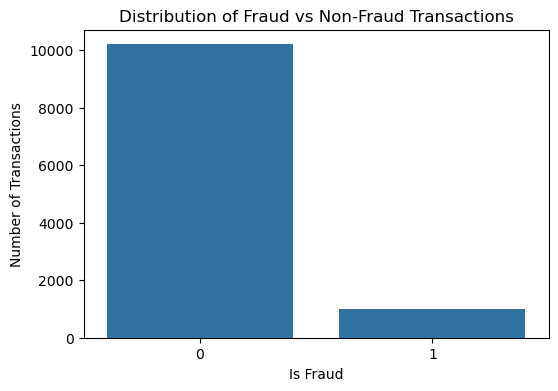

In [1413]:
# Visualize target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=data_clean, x='is_fraud')
plt.title('Distribution of Fraud vs Non-Fraud Transactions')
plt.xlabel('Is Fraud')
plt.ylabel('Number of Transactions')
plt.show()


The target variable remains imbalanced, with non-fraudulent transactions making up the majority of the dataset. This confirms that fraud detection performance should not be judged by accuracy alone. Later model evaluation should focus on recall, precision, F1-score, ROC-AUC, and PR-AUC.

In [1414]:
# Compare average numeric values by fraud status
numeric_summary_by_fraud = data_clean.groupby('is_fraud')[
    [
        'amount_usd',
        'fee',
        'exchange_rate_src_to_dest',
        'account_age_days',
        'chargeback_history_count',
        'risk_score_internal',
        'corridor_risk',
        'ip_risk_score',
        'device_trust_score',
        'txn_velocity_1h',
        'txn_velocity_24h'
    ]
].mean().T.round(2)

numeric_summary_by_fraud

is_fraud,0,1
amount_usd,394.04,1030.30
fee,104.51,56.68
exchange_rate_src_to_dest,149.22,354.46
account_age_days,423.40,79.54
chargeback_history_count,0.00,0.53
risk_score_internal,0.24,0.55
corridor_risk,0.04,0.10
ip_risk_score,0.34,0.85
device_trust_score,0.70,0.31
txn_velocity_1h,0.16,3.86


This table compares the average values of key numeric features for non-fraudulent and fraudulent transactions. Differences in transaction amount, account age, risk scores, device trust, and transaction velocity may indicate useful fraud patterns for later feature selection and modeling.

In [1415]:
# Summary statistics for transaction amount by fraud status
data_clean.groupby('is_fraud')['amount_usd'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,9912.0,394.04,1374.45,7.23,88.18,151.44,264.06,12498.57
1,988.0,1030.30,1528.74,15.98,268.77,548.06,1167.62,12496.24


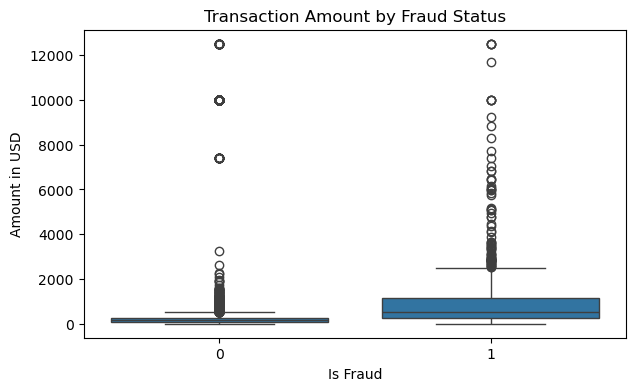

In [1416]:
# Boxplot of transaction amount by fraud status
plt.figure(figsize=(7, 4))
sns.boxplot(data=data_clean, x='is_fraud', y='amount_usd')
plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Amount in USD')
plt.show()

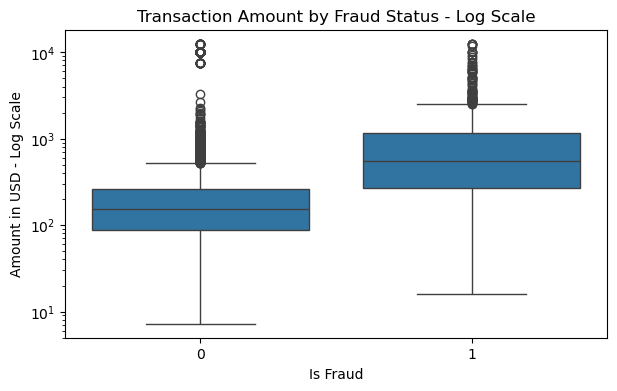

In [1417]:
# Boxplot with log-scaled y-axis for better visibility
plt.figure(figsize=(7, 4))
sns.boxplot(data=data_clean, x='is_fraud', y='amount_usd')
plt.yscale('log')
plt.title('Transaction Amount by Fraud Status - Log Scale')
plt.xlabel('Is Fraud')
plt.ylabel('Amount in USD - Log Scale')
plt.show()

In [1418]:
# Fraud rate by channel
channel_fraud_rate = data_clean.groupby('channel')['is_fraud'].agg(
    total_transactions='count',
    fraud_count='sum',
    fraud_rate='mean'
).sort_values(by='fraud_rate', ascending=False)

channel_fraud_rate['fraud_rate'] = (channel_fraud_rate['fraud_rate'] * 100).round(2)

channel_fraud_rate

,total_transactions,fraud_count,fraud_rate
channel,,,
WEB,3766,614,16.30
ATM,1002,81,8.08
MOBILE,6395,299,4.68


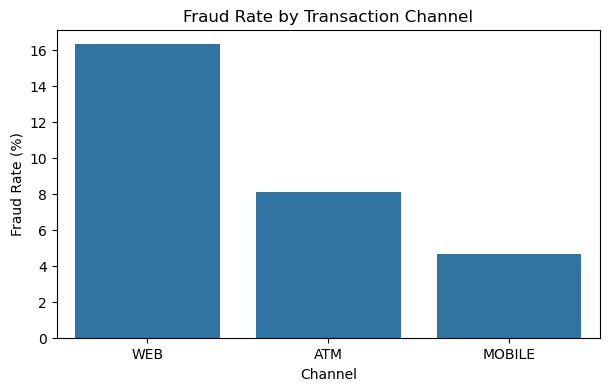

In [1419]:
# Visualize fraud rate by channel
plt.figure(figsize=(7, 4))
sns.barplot(
    data=channel_fraud_rate.reset_index(),
    x='channel',
    y='fraud_rate'
)
plt.title('Fraud Rate by Transaction Channel')
plt.xlabel('Channel')
plt.ylabel('Fraud Rate (%)')
plt.show()

In [1420]:
# Fraud rate by KYC tier
kyc_fraud_rate = data_clean.groupby('kyc_tier')['is_fraud'].agg(
    total_transactions='count',
    fraud_count='sum',
    fraud_rate='mean'
).sort_values(by='fraud_rate', ascending=False)

kyc_fraud_rate['fraud_rate'] = (kyc_fraud_rate['fraud_rate'] * 100).round(2)

kyc_fraud_rate

,total_transactions,fraud_count,fraud_rate
kyc_tier,,,
LOW,1047,536,51.19
STANDARD,7985,410,5.13
ENHANCED,1839,41,2.23


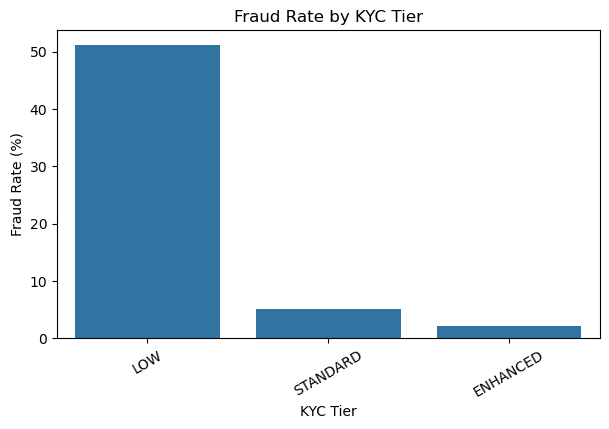

In [1421]:
# Visualize fraud rate by KYC tier
plt.figure(figsize=(7, 4))
sns.barplot(
    data=kyc_fraud_rate.reset_index(),
    x='kyc_tier',
    y='fraud_rate'
)
plt.title('Fraud Rate by KYC Tier')
plt.xlabel('KYC Tier')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=30)
plt.show()

In [1422]:
# Fraud rate by new device
new_device_fraud_rate = data_clean.groupby('new_device')['is_fraud'].agg(
    total_transactions='count',
    fraud_count='sum',
    fraud_rate='mean'
)

new_device_fraud_rate['fraud_rate'] = (new_device_fraud_rate['fraud_rate'] * 100).round(2)

new_device_fraud_rate

,total_transactions,fraud_count,fraud_rate
new_device,,,
False,9864,484,4.91
True,1336,511,38.25


In [1423]:
# Fraud rate by location mismatch
location_mismatch_fraud_rate = data_clean.groupby('location_mismatch')['is_fraud'].agg(
    total_transactions='count',
    fraud_count='sum',
    fraud_rate='mean'
)

location_mismatch_fraud_rate['fraud_rate'] = (location_mismatch_fraud_rate['fraud_rate'] * 100).round(2)

location_mismatch_fraud_rate

,total_transactions,fraud_count,fraud_rate
location_mismatch,,,
False,9375,338,3.61
True,1825,657,36.00


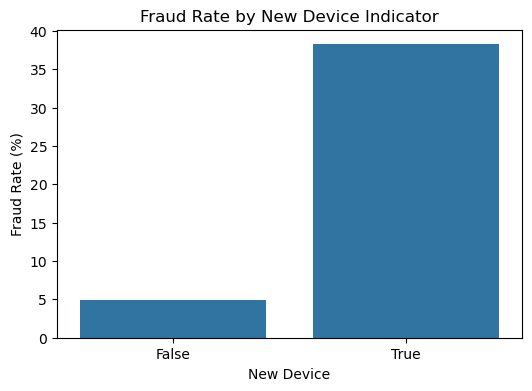

In [1424]:
# Visualize fraud rate by new device
plt.figure(figsize=(6, 4))
sns.barplot(
    data=new_device_fraud_rate.reset_index(),
    x='new_device',
    y='fraud_rate'
)
plt.title('Fraud Rate by New Device Indicator')
plt.xlabel('New Device')
plt.ylabel('Fraud Rate (%)')
plt.show()

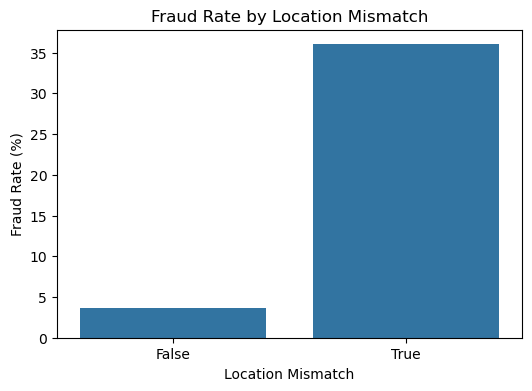

In [1425]:
# Visualize fraud rate by location mismatch
plt.figure(figsize=(6, 4))
sns.barplot(
    data=location_mismatch_fraud_rate.reset_index(),
    x='location_mismatch',
    y='fraud_rate'
)
plt.title('Fraud Rate by Location Mismatch')
plt.xlabel('Location Mismatch')
plt.ylabel('Fraud Rate (%)')
plt.show()

Initial Fraud Pattern Insights
The early EDA results show clear differences between fraudulent and non-fraudulent transactions. Fraudulent transactions tend to have higher transaction amounts, higher internal risk scores, higher IP risk scores, higher corridor risk, lower device trust scores, and much higher transaction velocity. Fraudulent transactions also appear to come from newer customer accounts on average.

Several categorical indicators also show strong fraud patterns. Web transactions have the highest fraud rate by channel, low KYC tier has a much higher fraud rate than standard or enhanced KYC tiers, transactions from new devices are much more likely to be fraudulent, and location mismatch is strongly associated with fraud.

These findings suggest that risk scores, account age, transaction velocity, KYC tier, new device status, and location mismatch may be important predictors during model development.

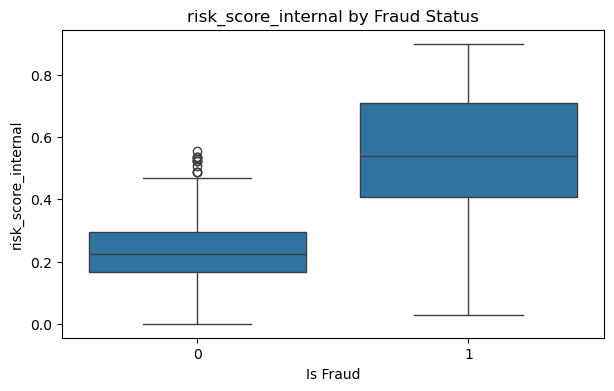

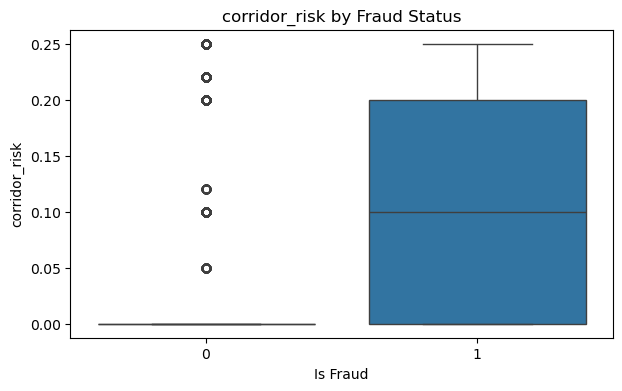

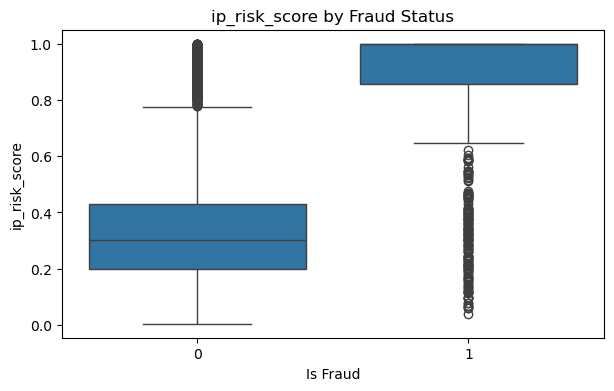

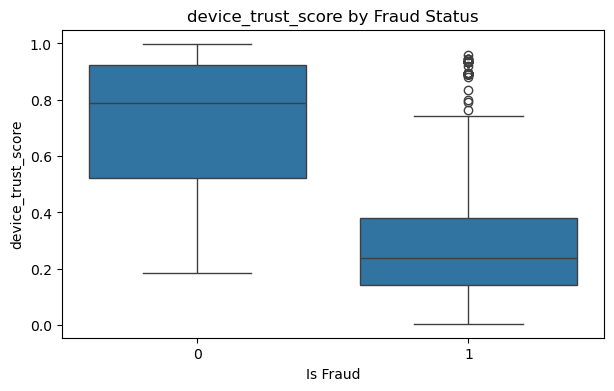

In [1426]:
# Compare risk score distributions by fraud status
risk_score_cols = [
    'risk_score_internal',
    'corridor_risk',
    'ip_risk_score',
    'device_trust_score'
]

for col in risk_score_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=data_clean, x='is_fraud', y=col)
    plt.title(f'{col} by Fraud Status')
    plt.xlabel('Is Fraud')
    plt.ylabel(col)
    plt.show()


In [1427]:
# Average risk scores by fraud status
risk_score_summary = data_clean.groupby('is_fraud')[risk_score_cols].mean().T.round(2)
risk_score_summary

is_fraud,0,1
risk_score_internal,0.24,0.55
corridor_risk,0.04,0.10
ip_risk_score,0.34,0.85
device_trust_score,0.70,0.31



Risk score variables show clear separation between fraudulent and non-fraudulent transactions. Fraudulent transactions have higher internal risk, corridor risk, and IP risk scores, while device trust scores are lower for fraudulent transactions. This pattern is consistent with the business expectation that risky transactions are more likely to involve suspicious IP behavior, high-risk corridors, and lower device trust.

In [1428]:
# Compare transaction velocity by fraud status
velocity_cols = ['txn_velocity_1h', 'txn_velocity_24h']

data_clean.groupby('is_fraud')[velocity_cols].describe().round(2)

txn_velocity_1h                                       \
                   count  mean   std  min  25%  50%  75%  max   
is_fraud                                                        
0                10009.0  0.16  0.92  0.0  0.0  0.0  0.0  8.0   
1                  991.0  3.86  2.26  0.0  3.0  4.0  5.0  8.0   

         txn_velocity_24h                                        
                    count  mean   std  min  25%  50%  75%   max  
is_fraud                                                         
0                 10205.0  0.27  0.99  0.0  0.0  0.0  0.0   9.0  
1                   995.0  5.48  2.98  0.0  4.0  6.0  8.0  11.0

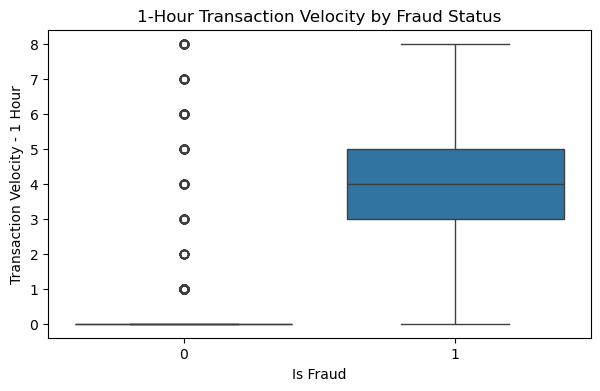

In [1429]:
# Boxplot of 1-hour transaction velocity by fraud status
plt.figure(figsize=(7, 4))
sns.boxplot(data=data_clean, x='is_fraud', y='txn_velocity_1h')
plt.title('1-Hour Transaction Velocity by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Velocity - 1 Hour')
plt.show()

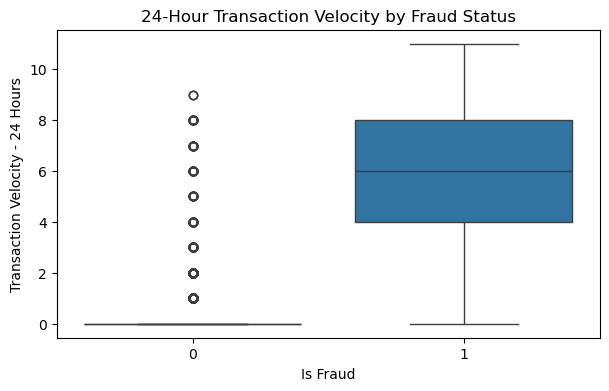

In [1430]:
# Boxplot of 24-hour transaction velocity by fraud status
plt.figure(figsize=(7, 4))
sns.boxplot(data=data_clean, x='is_fraud', y='txn_velocity_24h')
plt.title('24-Hour Transaction Velocity by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Velocity - 24 Hours')
plt.show()

Transaction velocity appears to be an important fraud signal. Fraudulent transactions show higher average transaction activity within both the 1-hour and 24-hour windows. This suggests that fraud may be associated with rapid repeated transaction attempts, which is common in account takeover or unauthorized payment scenarios.

In [1431]:
# Extract time-based features for EDA
data_clean['transaction_hour'] = data_clean['timestamp'].dt.hour
data_clean['transaction_day'] = data_clean['timestamp'].dt.day_name()
data_clean['transaction_month'] = data_clean['timestamp'].dt.month_name()

In [1432]:
# Fraud rate by transaction hour
hourly_fraud_rate = data_clean.groupby('transaction_hour')['is_fraud'].agg(
    total_transactions='count',
    fraud_count='sum',
    fraud_rate='mean'
)

hourly_fraud_rate['fraud_rate'] = (hourly_fraud_rate['fraud_rate'] * 100).round(2)

hourly_fraud_rate

,total_transactions,fraud_count,fraud_rate
transaction_hour,,,
0.0,465,29,6.24
1.0,414,26,6.28
2.0,421,33,7.84
3.0,495,61,12.32
4.0,509,94,18.47
5.0,487,77,15.81
6.0,478,99,20.71
7.0,460,82,17.83
8.0,485,62,12.78


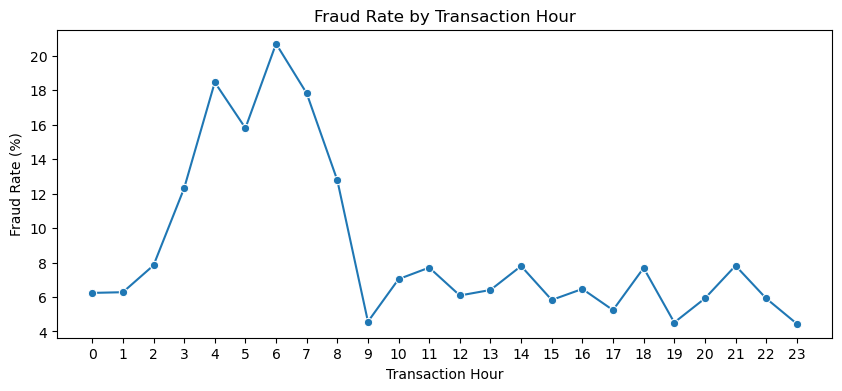

In [1433]:
# Visualize fraud rate by transaction hour
plt.figure(figsize=(10, 4))
sns.lineplot(
    data=hourly_fraud_rate.reset_index(),
    x='transaction_hour',
    y='fraud_rate',
    marker='o'
)
plt.title('Fraud Rate by Transaction Hour')
plt.xlabel('Transaction Hour')
plt.ylabel('Fraud Rate (%)')
plt.xticks(range(0, 24))
plt.show()

In [1434]:
# Fraud rate by transaction day
day_fraud_rate = data_clean.groupby('transaction_day')['is_fraud'].agg(
    total_transactions='count',
    fraud_count='sum',
    fraud_rate='mean'
)

day_fraud_rate['fraud_rate'] = (day_fraud_rate['fraud_rate'] * 100).round(2)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_fraud_rate = day_fraud_rate.reindex(day_order)

day_fraud_rate

,total_transactions,fraud_count,fraud_rate
transaction_day,,,
Monday,1624,134,8.25
Tuesday,1594,157,9.85
Wednesday,1562,129,8.26
Thursday,1636,157,9.60
Friday,1614,140,8.67
Saturday,1575,143,9.08
Sunday,1535,133,8.66


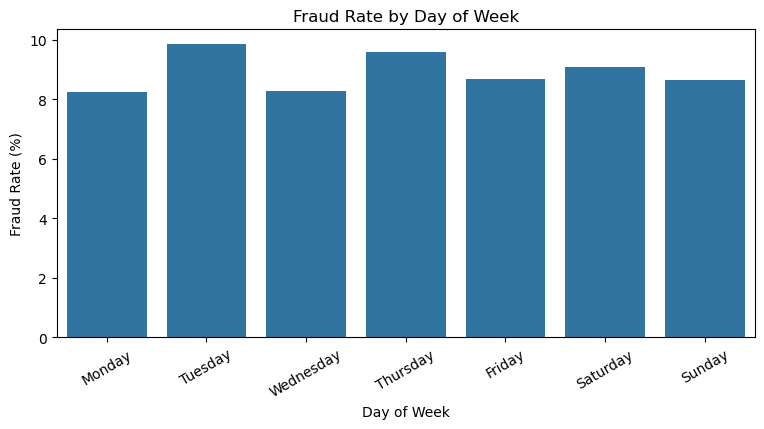

In [1435]:
# Visualize fraud rate by transaction day
plt.figure(figsize=(9, 4))
sns.barplot(
    data=day_fraud_rate.reset_index(),
    x='transaction_day',
    y='fraud_rate'
)
plt.title('Fraud Rate by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation=30)
plt.show()

Risk Score and Time-Based Insights
The risk score variables show strong differences between fraudulent and non-fraudulent transactions. Fraudulent transactions have higher average internal risk scores, corridor risk, and IP risk scores. They also have much lower average device trust scores, suggesting that suspicious IP activity, higher-risk transaction corridors, and lower device trust may be important fraud indicators.

The hourly fraud pattern also shows a noticeable spike during the early morning hours, especially between 3:00 and 8:00, with the highest fraud rate around 6:00. This suggests that transaction hour may be useful as a time-based feature during modeling.

Rows with missing timestamps were excluded from the time-based fraud rate analysis because transaction hour and day of week could not be derived for those records.

Fraud rates by day of week are more similar across days, with only small differences between weekdays and weekends. This suggests that day of week may be less predictive than transaction hour, but it may still be useful to retain during feature engineering.

In [1436]:
# Fraud rate by home country
home_country_fraud_rate = data_clean.groupby('home_country')['is_fraud'].agg(
    total_transactions='count',
    fraud_count='sum',
    fraud_rate='mean'
).sort_values(by='fraud_rate', ascending=False)

home_country_fraud_rate['fraud_rate'] = (home_country_fraud_rate['fraud_rate'] * 100).round(2)

home_country_fraud_rate

,total_transactions,fraud_count,fraud_rate
home_country,,,
CA,1212,185,15.26
UK,2104,281,13.36
US,7852,528,6.72


In [1437]:
# Fraud rate by IP country
ip_country_fraud_rate = data_clean.groupby('ip_country')['is_fraud'].agg(
    total_transactions='count',
    fraud_count='sum',
    fraud_rate='mean'
).sort_values(by='fraud_rate', ascending=False)

ip_country_fraud_rate['fraud_rate'] = (ip_country_fraud_rate['fraud_rate'] * 100).round(2)

ip_country_fraud_rate

,total_transactions,fraud_count,fraud_rate
ip_country,,,
CA,1718,304,17.69
UK,2390,359,15.02
US,6761,325,4.81


In [1438]:
# Create currency corridor feature
data_clean['currency_corridor'] = (
    data_clean['source_currency'].astype(str) + ' → ' + data_clean['dest_currency'].astype(str)
)

# Fraud rate by currency corridor
corridor_fraud_rate = data_clean.groupby('currency_corridor')['is_fraud'].agg(
    total_transactions='count',
    fraud_count='sum',
    fraud_rate='mean'
).sort_values(by='fraud_rate', ascending=False)

corridor_fraud_rate['fraud_rate'] = (corridor_fraud_rate['fraud_rate'] * 100).round(2)

corridor_fraud_rate

,total_transactions,fraud_count,fraud_rate
currency_corridor,,,
CAD → INR,177,107,60.45
GBP → NGN,311,122,39.23
USD → MXN,488,129,26.43
GBP → EUR,136,20,14.71
USD → NGN,1012,134,13.24
CAD → NGN,124,15,12.10
USD → PHP,939,112,11.93
GBP → CNY,252,25,9.92
GBP → USD,240,22,9.17


In [1439]:
# Filter corridors with at least 100 transactions for more reliable comparison
corridor_fraud_rate_100 = corridor_fraud_rate[
    corridor_fraud_rate['total_transactions'] >= 100
].sort_values(by='fraud_rate', ascending=False)

corridor_fraud_rate_100

,total_transactions,fraud_count,fraud_rate
currency_corridor,,,
CAD → INR,177,107,60.45
GBP → NGN,311,122,39.23
USD → MXN,488,129,26.43
GBP → EUR,136,20,14.71
USD → NGN,1012,134,13.24
CAD → NGN,124,15,12.10
USD → PHP,939,112,11.93
GBP → CNY,252,25,9.92
GBP → USD,240,22,9.17


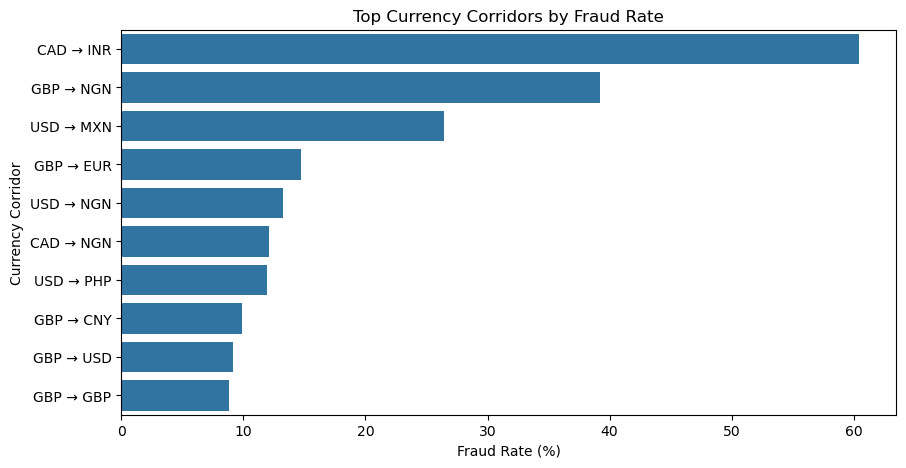

In [1440]:
# Visualize top currency corridors by fraud rate
plt.figure(figsize=(10, 5))
sns.barplot(
    data=corridor_fraud_rate_100.head(10).reset_index(),
    x='fraud_rate',
    y='currency_corridor'
)
plt.title('Top Currency Corridors by Fraud Rate')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('Currency Corridor')
plt.show()


In [1441]:
# Fee summary by fraud status
data_clean.groupby('is_fraud')['fee'].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,9822.0,104.51,983.38,0.5,2.33,3.34,5.02,9999.99
1,988.0,56.68,634.68,0.5,5.09,9.40,18.50,9999.99


In [1442]:
# Median fee by fraud status
data_clean.groupby('is_fraud')['fee'].median().round(2)

is_fraud
0    3.34
1    9.40
Name: fee, dtype: float64

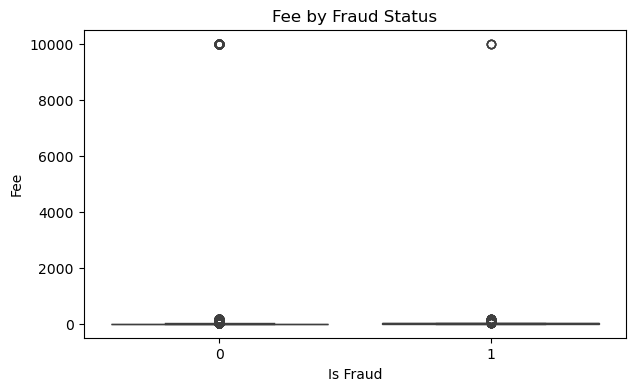

In [1443]:
# Boxplot of fee by fraud status
plt.figure(figsize=(7, 4))
sns.boxplot(data=data_clean, x='is_fraud', y='fee')
plt.title('Fee by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Fee')
plt.show()

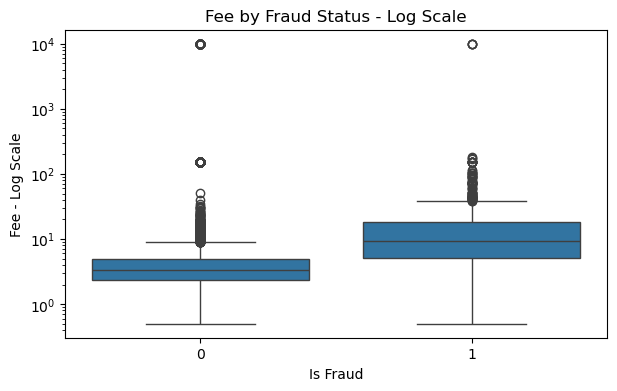

In [1444]:
# Boxplot of fee by fraud status using log scale
plt.figure(figsize=(7, 4))
sns.boxplot(data=data_clean, x='is_fraud', y='fee')
plt.yscale('log')
plt.title('Fee by Fraud Status - Log Scale')
plt.xlabel('Is Fraud')
plt.ylabel('Fee - Log Scale')
plt.show()

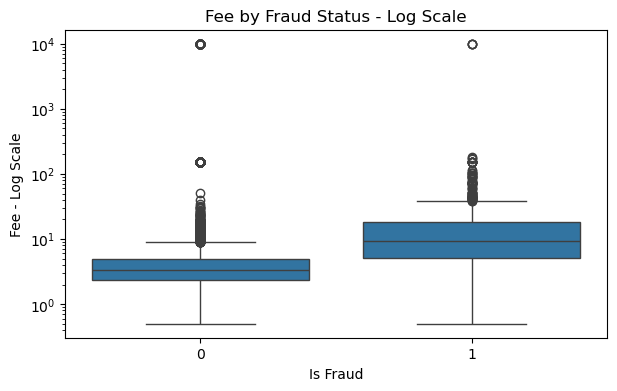

In [1445]:
# Boxplot of fee by fraud status using log scale
plt.figure(figsize=(7, 4))
sns.boxplot(data=data_clean, x='is_fraud', y='fee')
plt.yscale('log')
plt.title('Fee by Fraud Status - Log Scale')
plt.xlabel('Is Fraud')
plt.ylabel('Fee - Log Scale')
plt.show()

In [1446]:
# Correlation of numeric variables with fraud target
numeric_cols = data_clean.select_dtypes(include=['int64', 'float64', 'bool']).columns

corr_with_target = data_clean[numeric_cols].corr()['is_fraud'].sort_values(ascending=False)

corr_with_target

is_fraud                     1.000000
txn_velocity_24h             0.752129
txn_velocity_1h              0.692339
risk_score_internal          0.603606
ip_risk_score                0.585175
chargeback_history_count     0.580417
location_mismatch            0.420506
new_device                   0.379840
corridor_risk                0.194903
exchange_rate_src_to_dest    0.152899
amount_usd                   0.130389
amount_src                   0.129664
fee                         -0.014406
transaction_hour            -0.087203
account_age_days            -0.285965
device_trust_score          -0.440763
Name: is_fraud, dtype: float64

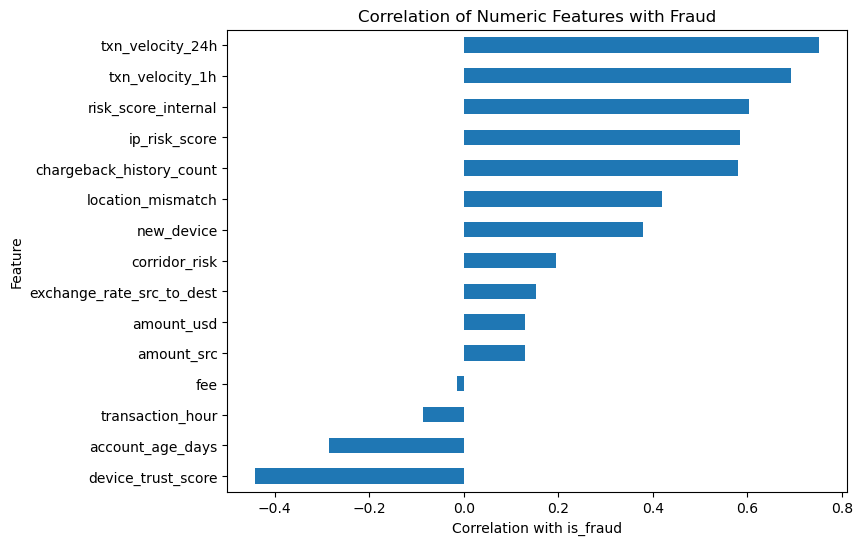

In [1447]:
# Visualize correlation with target
plt.figure(figsize=(8, 6))
corr_with_target.drop('is_fraud').sort_values().plot(kind='barh')
plt.title('Correlation of Numeric Features with Fraud')
plt.xlabel('Correlation with is_fraud')
plt.ylabel('Feature')
plt.show()

Corridor, Fee, and Correlation Insights
The geography analysis also shows differences in fraud rates by home country and IP country. Transactions associated with Canada and the United Kingdom show higher fraud rates than those associated with the United States in this dataset. This suggests that location-based features may provide useful fraud signals, especially when combined with location mismatch, IP risk score, and currency corridor information.

Currency corridor appears to be an important fraud signal. Some corridors show much higher fraud rates than others, especially CAD → INR, GBP → NGN, and USD → MXN. Because corridor-level fraud rates can be affected by transaction volume, the analysis focused on corridors with at least 100 transactions to avoid over-interpreting very small groups.

The fee analysis suggests that the average fee may be influenced by extreme outliers, since both fraud and non-fraud transactions have very high maximum fee values. However, the median fee is higher for fraudulent transactions, which may indicate that fee-related patterns could still be useful during modeling.

The correlation analysis shows that transaction velocity, internal risk score, IP risk score, chargeback history, location mismatch, and new device indicators are positively associated with fraud. In contrast, device trust score and account age are negatively associated with fraud, suggesting that fraud is more likely among newer accounts and lower-trust devices.

EDA Summary
The exploratory data analysis revealed several meaningful fraud patterns in the NovaPay dataset. Fraudulent transactions tend to have higher transaction amounts, higher transaction velocity, higher internal and IP risk scores, higher corridor risk, more chargeback history, lower device trust scores, and shorter account age.

Categorical patterns also showed strong fraud signals. Fraud rates were higher for web transactions, low KYC tier customers, new device transactions, and transactions with location mismatch. Some currency corridors also showed elevated fraud rates, suggesting that transaction route may be useful for model development.

Time-based analysis showed that fraud rates were noticeably higher during early morning hours, while fraud rates by day of week were more evenly distributed. Overall, the EDA suggests that device behavior, customer verification level, account history, location mismatch, transaction velocity, risk scores, and corridor patterns are likely to be important predictors for fraud detection.

3. Feature Engineering and Preprocessing
In this section, I will prepare the cleaned NovaPay dataset for machine learning. This includes creating fraud-relevant features, selecting model input variables, separating the target variable, splitting the data into training and testing sets, and building preprocessing pipelines for numeric and categorical variables.

To avoid data leakage, preprocessing steps such as imputation, scaling, and encoding will be fit only on the training data and then applied to the test data.

In [1448]:
# Create a copy for feature engineering and preprocessing
data_model = data_clean.copy()

data_model.shape

(11200, 30)

In [1449]:
# Ensure timestamp is in datetime format
data_model['timestamp'] = pd.to_datetime(
    data_model['timestamp'],
    errors='coerce',
    utc=True)


In [1450]:
# Create time-based features
data_model['transaction_hour'] = data_model['timestamp'].dt.hour
data_model['transaction_dayofweek'] = data_model['timestamp'].dt.dayofweek
data_model['transaction_month'] = data_model['timestamp'].dt.month
data_model['is_weekend'] = data_model['transaction_dayofweek'].isin([5, 6]).astype(int)

# Create missing timestamp indicator
data_model['missing_timestamp'] = data_model['timestamp'].isna().astype(int)

Time-based features were created from the transaction timestamp because the EDA showed that fraud rates varied by transaction hour, especially during early morning hours. A missing timestamp indicator was also created so that missing timestamp information is not completely lost during modeling

In [1451]:
# Create log-transformed amount and fee features to reduce skewness
data_model['amount_usd_log'] = np.log1p(data_model['amount_usd'])
data_model['fee_log'] = np.log1p(data_model['fee'])

# Create fee rate feature
data_model['fee_rate'] = data_model['fee'] / data_model['amount_usd']

# Replace infinite values with missing values
data_model = data_model.replace([np.inf, -np.inf], np.nan)

Log-transformed amount and fee features were created because transaction amount and fee values were skewed and contained outliers. A fee rate feature was also created to capture the fee relative to the transaction amount.

In [1452]:
# Create currency corridor feature
data_model['currency_corridor'] = (
    data_model['source_currency'].astype(str) + ' → ' + data_model['dest_currency'].astype(str)
)

# Create home country and IP country mismatch indicator
data_model['ip_home_country_mismatch'] = np.where(
    data_model['home_country'].isna() | data_model['ip_country'].isna(),
    np.nan,
    (data_model['home_country'] != data_model['ip_country']).astype(int))


A currency corridor feature was created because EDA showed that some source-to-destination currency routes had much higher fraud rates than others. A home country and IP country mismatch indicator was also created to capture possible location inconsistencies that may signal suspicious transaction behavior.

In [1453]:
# Drop columns that should not be used directly as model features
columns_to_drop = [
    'is_fraud',
    'transaction_id',
    'customer_id',
    'timestamp',
    'ip_address',
    'device_id',
    'transaction_day'  # EDA-only column, if present
]
X = data_model.drop(columns=[col for col in columns_to_drop if col in data_model.columns])
y = data_model['is_fraud']

X.shape, y.shape

((11200, 30), (11200,))

The target variable was separated from the feature set. Identifier columns such as transaction ID, customer ID, IP address, and device ID were removed because they are high-cardinality identifiers and may not generalize well to new transactions. The raw timestamp was also removed after deriving useful time-based features from it.

In [1454]:
# Review final feature columns
X.columns

Index(['home_country', 'source_currency', 'dest_currency', 'channel',
       'amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest',
       'new_device', 'ip_country', 'location_mismatch', 'ip_risk_score',
       'kyc_tier', 'account_age_days', 'device_trust_score',
       'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h',
       'txn_velocity_24h', 'corridor_risk', 'transaction_hour',
       'transaction_month', 'currency_corridor', 'transaction_dayofweek',
       'is_weekend', 'missing_timestamp', 'amount_usd_log', 'fee_log',
       'fee_rate', 'ip_home_country_mismatch'],
      dtype='object')

In [1455]:
# Check data types of selected model features
X.dtypes

home_country                  object
source_currency               object
dest_currency                 object
channel                       object
amount_src                   float64
amount_usd                   float64
fee                          float64
exchange_rate_src_to_dest    float64
new_device                      bool
ip_country                    object
location_mismatch               bool
ip_risk_score                float64
kyc_tier                      object
account_age_days               int64
device_trust_score           float64
chargeback_history_count       int64
risk_score_internal          float64
txn_velocity_1h              float64
txn_velocity_24h             float64
corridor_risk                float64
transaction_hour             float64
transaction_month            float64
currency_corridor             object
transaction_dayofweek        float64
is_weekend                     int64
missing_timestamp              int64
amount_usd_log               float64
f

In [1456]:

# Check feature matrix preview
X.head()

,home_country,source_currency,dest_currency,channel,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,ip_country,location_mismatch,ip_risk_score,kyc_tier,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,transaction_hour,transaction_month,currency_corridor,transaction_dayofweek,is_weekend,missing_timestamp,amount_usd_log,fee_log,fee_rate,ip_home_country_mismatch
0,US,USD,CAD,ATM,278.19,278.19,4.25,1.351351,False,US,False,0.123,STANDARD,263,0.522,0,0.223,0.0,0.0,0.0,18.0,10.0,USD → CAD,0.0,0,0,5.631893,1.658228,0.015277,0.0
1,CA,CAD,MXN,WEB,208.51,154.29,4.24,12.758621,True,CA,False,0.569,STANDARD,947,0.475,0,0.268,0.0,1.0,0.0,20.0,10.0,CAD → MXN,0.0,0,0,5.045294,1.656321,0.027481,0.0
2,US,USD,CNY,MOBILE,160.33,160.33,2.70,7.142857,False,US,False,0.437,ENHANCED,367,0.939,0,0.176,0.0,0.0,0.0,23.0,10.0,USD → CNY,0.0,0,0,5.083452,1.308333,0.016840,0.0
3,US,USD,EUR,MOBILE,59.41,59.41,2.22,0.925926,False,US,False,0.594,STANDARD,147,0.551,0,0.391,0.0,0.0,0.0,1.0,10.0,USD → EUR,1.0,0,0,4.101155,1.169381,0.037367,0.0
4,US,USD,INR,MOBILE,200.96,200.96,3.61,83.333333,False,US,False,0.121,ENHANCED,257,0.894,0,0.257,0.0,0.0,0.0,9.0,10.0,USD → INR,1.0,0,0,5.308070,1.528228,0.017964,0.0


In [1457]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets using stratification to preserve fraud balance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((8960, 30), (2240, 30), (8960,), (2240,))

In [1458]:
# Function to check target distribution
def target_distribution(series):
    return pd.DataFrame({
        'Count': series.value_counts(),
        'Percentage': series.value_counts(normalize=True).mul(100).round(2)
    })

target_distribution(y_train)

,Count,Percentage
is_fraud,,
0,8164,91.12
1,796,8.88


In [1459]:
target_distribution(y_test)

,Count,Percentage
is_fraud,,
0,2041,91.12
1,199,8.88



The dataset was split into training and testing sets using stratified sampling. This preserves the fraud/non-fraud distribution in both sets, which is important because fraud is the minority class.

In [1460]:
# Identify numeric and categorical columns
numeric_features = X_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32', 'bool']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

print("Number of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Number of numeric features: 23
Number of categorical features: 7

Numeric features:
['amount_src', 'amount_usd', 'fee', 'exchange_rate_src_to_dest', 'new_device', 'location_mismatch', 'ip_risk_score', 'account_age_days', 'device_trust_score', 'chargeback_history_count', 'risk_score_internal', 'txn_velocity_1h', 'txn_velocity_24h', 'corridor_risk', 'transaction_hour', 'transaction_month', 'transaction_dayofweek', 'is_weekend', 'missing_timestamp', 'amount_usd_log', 'fee_log', 'fee_rate', 'ip_home_country_mismatch']

Categorical features:
['home_country', 'source_currency', 'dest_currency', 'channel', 'ip_country', 'kyc_tier', 'currency_corridor']


The model features were separated into numeric and categorical groups so that each type could be preprocessed appropriately. Numeric features will be imputed and scaled, while categorical features will be imputed and one-hot encoded.

In [1461]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


In [1462]:
# Numeric preprocessing: impute missing values with median and scale features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing: impute missing values with most frequent value and one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine numeric and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['amount_src', 'amount_usd', 'fee',
                                  'exchange_rate_src_to_dest', 'new_device',
                                  'location_mismatch', 'ip_risk_score',
                                  'account_age_days', 'device_trust_score',
                                  'chargeback_history_count',
                                  'risk_score_internal', 'txn_velocity_1h',
                                  'tx...
                                  'transaction_dayofweek', 'is_weekend',
                                  'missing_timestamp', 'amount_usd_log',
                                  'fee_log', 'fee_rate',
                                  'ip_home_country_mismatch']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['home_country', 'source_currency',
                                  'dest_currency', 'channel', 'ip_country',
                                  'kyc_tier', 'currency_corridor'])])

The preprocessing pipeline handles missing values and prepares the data for machine learning. Median imputation was used for numeric variables because it is more robust to outliers than mean imputation. Most-frequent imputation was used for categorical variables, and one-hot encoding was applied so that categorical values can be used by machine learning models.

The preprocessing object will be fit only on the training data to avoid data leakage, then applied to the test data.

In [1463]:
# Fit preprocessing on training data and transform both training and test sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

X_train_processed.shape, X_test_processed.shape

((8960, 74), (2240, 74))

The preprocessing pipeline was fit only on the training data and then applied to both the training and test sets. This ensures that information from the test set does not influence preprocessing decisions such as imputation values or encoded categories.

In [1464]:
# Get processed feature names after preprocessing
encoded_categorical_features = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)

processed_feature_names = numeric_features + encoded_categorical_features.tolist()

len(processed_feature_names)

74

In [1465]:
# Preview processed feature names
processed_feature_names[:30]

['amount_src',
 'amount_usd',
 'fee',
 'exchange_rate_src_to_dest',
 'new_device',
 'location_mismatch',
 'ip_risk_score',
 'account_age_days',
 'device_trust_score',
 'chargeback_history_count',
 'risk_score_internal',
 'txn_velocity_1h',
 'txn_velocity_24h',
 'corridor_risk',
 'transaction_hour',
 'transaction_month',
 'transaction_dayofweek',
 'is_weekend',
 'missing_timestamp',
 'amount_usd_log',
 'fee_log',
 'fee_rate',
 'ip_home_country_mismatch',
 'home_country_CA',
 'home_country_UK',
 'home_country_US',
 'source_currency_CAD',
 'source_currency_GBP',
 'source_currency_USD',
 'dest_currency_CAD']

In [1466]:
# Convert processed data into DataFrames for easier inspection
X_train_processed_df = pd.DataFrame(
    X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed,
    columns=processed_feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed,
    columns=processed_feature_names,
    index=X_test.index
)

X_train_processed_df.head()

,amount_src,amount_usd,fee,exchange_rate_src_to_dest,new_device,location_mismatch,ip_risk_score,account_age_days,device_trust_score,chargeback_history_count,risk_score_internal,txn_velocity_1h,txn_velocity_24h,corridor_risk,transaction_hour,transaction_month,transaction_dayofweek,is_weekend,missing_timestamp,amount_usd_log,fee_log,fee_rate,ip_home_country_mismatch,home_country_CA,home_country_UK,home_country_US,source_currency_CAD,source_currency_GBP,source_currency_USD,dest_currency_CAD,dest_currency_CNY,dest_currency_EUR,dest_currency_GBP,dest_currency_INR,dest_currency_MXN,dest_currency_NGN,dest_currency_PHP,dest_currency_USD,channel_ATM,channel_MOBILE,channel_WEB,ip_country_CA,ip_country_UK,ip_country_US,kyc_tier_ENHANCED,kyc_tier_LOW,kyc_tier_STANDARD,currency_corridor_CAD → CAD,currency_corridor_CAD → CNY,currency_corridor_CAD → EUR,currency_corridor_CAD → GBP,currency_corridor_CAD → INR,currency_corridor_CAD → MXN,currency_corridor_CAD → NGN,currency_corridor_CAD → PHP,currency_corridor_CAD → USD,currency_corridor_GBP → CAD,currency_corridor_GBP → CNY,currency_corridor_GBP → EUR,currency_corridor_GBP → GBP,currency_corridor_GBP → INR,currency_corridor_GBP → MXN,currency_corridor_GBP → NGN,currency_corridor_GBP → PHP,currency_corridor_GBP → USD,currency_corridor_USD → CAD,currency_corridor_USD → CNY,currency_corridor_USD → EUR,currency_corridor_USD → GBP,currency_corridor_USD → INR,currency_corridor_USD → MXN,currency_corridor_USD → NGN,currency_corridor_USD → PHP,currency_corridor_USD → USD
7262,-0.251565,-0.253977,-0.097876,-0.438073,-0.366106,2.263714,1.342299,-0.382453,-0.591689,-0.19332,-0.306560,-0.31674,-0.370209,-0.534887,0.508365,1.597247,1.017336,1.604367,-0.071047,-0.647653,-0.619572,-0.071306,2.312057,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8202,-0.304338,-0.306342,-0.098524,-0.395603,-0.366106,-0.441752,-1.241223,-0.078717,1.076959,-0.19332,-0.633997,-0.31674,-0.370209,1.819904,-1.378525,-1.023023,-1.495712,-0.623299,-0.071047,-2.057113,-0.842624,-0.066859,-0.432515,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2433,-0.231254,-0.211858,-0.096657,-0.438073,2.731449,-0.441752,0.012486,-1.138873,0.288653,-0.19332,0.975319,-0.31674,-0.370209,-0.534887,1.088947,-0.149600,-0.490493,-0.623299,-0.071047,-0.180987,-0.298916,-0.071393,-0.432515,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
810,-0.283607,-0.285772,-0.098272,-0.286869,-0.366106,-0.441752,-0.740540,-0.382453,-0.591689,-0.19332,-0.306560,-0.31674,-0.370209,0.642508,-0.652798,-1.605306,-1.495712,-0.623299,-0.071047,-1.255453,-0.749779,-0.070156,-0.432515,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2834,-0.094911,-0.042750,-0.093615,-0.438073,-0.366106,2.263714,-0.608360,-1.138873,0.888886,-0.19332,0.975319,-0.31674,-0.370209,-0.534887,0.508365,0.432683,-0.993103,-0.623299,-0.071047,0.722057,0.225845,-0.071909,2.312057,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [1467]:
# Check processed train and test shapes
X_train_processed_df.shape, X_test_processed_df.shape

((8960, 74), (2240, 74))

In [1468]:
# Confirm no missing values remain after preprocessing
X_train_processed_df.isnull().sum().sum(), X_test_processed_df.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [1469]:
# Confirm target distributions are unchanged
target_distribution(y_train), target_distribution(y_test)

(          Count  Percentage
 is_fraud                   
 0          8164       91.12
 1           796        8.88,
           Count  Percentage
 is_fraud                   
 0          2041       91.12
 1           199        8.88)

Modeling Assumption
This project assumes that features such as risk_score_internal, ip_risk_score, corridor_risk, device_trust_score, and chargeback_history_count are available at the time a transaction is scored. If any of these variables are generated only after a fraud investigation is completed, they would need to be removed from the model to avoid data leakage.

Feature Engineering and Preprocessing Summary
Feature engineering created additional fraud-relevant variables, including time-based features, log-transformed transaction amount and fee features, fee rate, currency corridor, and home-country/IP-country mismatch. These features were based on patterns identified during EDA, including differences in fraud rates by transaction hour, transaction corridor, device behavior, and location mismatch.

Identifier fields such as transaction ID, customer ID, IP address, and device ID were removed from the model feature set because they are high-cardinality identifiers and may not generalize well to unseen transactions. The target variable was separated from the feature matrix before preprocessing.

The data was split into training and test sets using stratified sampling, preserving the fraud distribution in both sets. Numeric features were imputed using the median and scaled, while categorical features were imputed using the most frequent value and one-hot encoded. The preprocessing pipeline was fit only on the training data and then applied to the test data to avoid data leakage.

After preprocessing, the training set contains 8,960 records and 74 processed features, while the test set contains 2,240 records and 74 processed features. No missing values remain in either processed dataset. At this stage, the data is ready for baseline model development.